In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

In [3]:
!pip install kagglehub
!pip install ipywidgets


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import kagglehub

kagglehub.login()

In [129]:
path = kagglehub.dataset_download("ky1338/10000-movies-letterboxd-data")

print("Path to dataset files:", path)

Path to dataset files: /Users/holyniewski/.cache/kagglehub/datasets/ky1338/10000-movies-letterboxd-data/versions/1


In [176]:
df = pd.read_csv("/Users/holyniewski/.cache/kagglehub/datasets/ky1338/10000-movies-letterboxd-data/versions/1/Movie_Data_File.csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Film_title,Release_year,Director,Cast,Average_rating,Owner_rating,Genres,Runtime,Countries,Original_language,...,★½,★★,★★½,★★★,★★★½,★★★★,★★★★½,★★★★★,Total_ratings,Film_URL
0,The Fan,NaN,Eckhart Schmidt,"['Désirée Nosbusch', 'Bodo Staiger', 'Simone B...",3.57,NaN,"['Horror', 'Drama']",92.0,['Germany'],German,...,103,402,525,1660,1950,2646,808,714,9042,https://letterboxd.com/film/the-fan-1982/
1,Mad Max: Fury Road,NaN,George Miller,"['Tom Hardy', 'Charlize Theron', 'Nicholas Hou...",4.18,4.5,"['Adventure', 'Science Fiction', 'Action']",121.0,"['Australia', 'USA']",English,...,6139,37471,30112,158356,163753,477901,280815,511140,1682389,https://letterboxd.com/film/mad-max-fury-road/
2,Suspiria,NaN,Dario Argento,"['Jessica Harper', 'Stefania Casini', 'Flavio ...",3.93,4.0,['Horror'],99.0,['Italy'],English,...,2710,11006,14397,53427,70309,138742,60628,88628,443757,https://letterboxd.com/film/suspiria/
3,Lost in Translation,NaN,Sofia Coppola,"['Bill Murray', 'Scarlett Johansson', 'Akiko T...",3.79,4.5,"['Drama', 'Comedy', 'Romance']",102.0,"['UK', 'USA']",English,...,11281,45997,46716,155110,166638,314160,122359,193717,1076949,https://letterboxd.com/film/lost-in-translation/
4,Akira,NaN,Katsuhiro Otomo,"['Mitsuo Iwata', 'Nozomu Sasaki', 'Mami Koyama...",4.28,5.0,"['Animation', 'Action', 'Science Fiction']",124.0,['Japan'],Japanese,...,1663,7286,9544,40850,61104,168485,112657,196532,600721,https://letterboxd.com/film/akira/


In [177]:
#release year is empty, owner rating is almost empty, url is not needed
df = df.drop(columns=["Release_year"])
df = df.drop(columns=["Film_URL", "Owner_rating"])

In [178]:
# filling missing values in Average_rating with the mean of the column
df["Average_rating"].mean()
df["Average_rating"]=df["Average_rating"].fillna(df["Average_rating"].mean())

In [179]:
# deleting rows with missing data in critical columns
df = df.dropna(subset=[
    "Average_rating",
    "Genres",
    "Runtime",
    "Description"
])

# because no movie can have 0 minutes
df.loc[df["Runtime"] == 0, "Runtime"] = np.nan

df = df.dropna(subset=["Runtime"])

In [180]:
df = df.drop_duplicates()

In [181]:
# making sure numeric columns stay numeric
numeric_columns = [
    "Runtime",
    "Average_rating",
    "Watches",
    "Likes",
    "Fans",
    "Total_ratings"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [182]:
# text pruning
text_columns = [
    "Film_title",
    "Director",
    "Cast",
    "Genres",
    "Countries",
    "Description"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

In [183]:
df.isnull().sum()

Film_title             0
Director               0
Cast                   0
Average_rating         0
Genres                 0
Runtime                0
Countries              0
Original_language      2
Spoken_languages       2
Description            0
Studios              286
Watches                0
List_appearances       0
Likes                  0
Fans                   0
½                      0
★                      0
★½                     0
★★                     0
★★½                    0
★★★                    0
★★★½                   0
★★★★                   0
★★★★½                  0
★★★★★                  0
Total_ratings          0
dtype: int64

In [184]:
# too much rows to just drop in my opinion
df["Studios"] = df["Studios"].fillna("Unknown")

In [229]:
df = df.dropna()

In [186]:
star_cols = [
"½","★","★½","★★","★★½",
"★★★","★★★½","★★★★","★★★★½","★★★★★"
]

df.loc[df["Total_ratings"] == 0, star_cols] = 0

for col in star_cols:
    df[col] = df[col] / df["Total_ratings"]

In [187]:
# number normalisation
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = [
    "Runtime",
    "Watches",
    "List_appearances",
    "Likes",
    "Fans",
    "Total_ratings"
]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [188]:
import ast

df["Genres"] = df["Genres"].apply(ast.literal_eval)

genres = df["Genres"].explode().str.get_dummies().groupby(level=0).sum()

df = pd.concat([df, genres], axis=1)

In [189]:
#print out every collumn name
print(df.columns)

Index(['Film_title', 'Director', 'Cast', 'Average_rating', 'Genres', 'Runtime',
       'Countries', 'Original_language', 'Spoken_languages', 'Description',
       'Studios', 'Watches', 'List_appearances', 'Likes', 'Fans', '½', '★',
       '★½', '★★', '★★½', '★★★', '★★★½', '★★★★', '★★★★½', '★★★★★',
       'Total_ratings', 'Action', 'Adventure', 'Animation',
       'Captivating vision and Shakespearean drama', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Epic adventure and breathtaking battles',
       'Epic heroes', 'Epic history and literature', 'Family', 'Fantasy',
       'Fantasy adventure, heroism, and swordplay',
       'Historical battles and epic heroism', 'History', 'Horror', 'Music',
       'Mystery', 'Romance', 'Science Fiction', 'Show All…',
       'Superheroes in action-packed battles with villains', 'TV Movie',
       'Thriller', 'War', 'Western'],
      dtype='object')


In [209]:
print(df.describe())

       Average_rating      Runtime      Watches  List_appearances  \
count     9934.000000  9934.000000  9934.000000       9934.000000   
mean         3.268870     0.111925     0.032942          0.033554   
std          0.526317     0.041854     0.088469          0.070772   
min          1.080000     0.000000     0.000000          0.000000   
25%          2.950000     0.096133     0.000590          0.002062   
50%          3.268535     0.107182     0.003601          0.008139   
75%          3.620000     0.122652     0.021093          0.030082   
max          4.710000     1.000000     1.000000          1.000000   

             Likes         Fans            ½            ★           ★½  \
count  9934.000000  9934.000000  9932.000000  9932.000000  9932.000000   
mean      0.016105     0.005102     0.018842     0.036371     0.036673   
std       0.055655     0.028829     0.044094     0.050415     0.041071   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%     

In [212]:
df.sample(3).T

,5946,7979,5459
Film_title,Zombeavers,Shadow,The Odyssey
Director,Jordan Rubin,Zhang Yimou,Jérôme Salle
Cast,"['Rachel Melvin', 'Cortney Palm', 'Lexi Atkins...","['Deng Chao', 'Sun Li', 'Ryan Zheng', 'Wang Qi...","['Lambert Wilson', 'Pierre Niney', 'Audrey Tau..."
Average_rating,2.31,3.63,3.32
Genres,"[Horror, Comedy, Action]","[Action, War]","[Drama, Adventure]"
Runtime,0.082873,0.125967,0.132597
Countries,['USA'],"['China', 'Hong Kong']",['France']
Original_language,English,Chinese,French
Spoken_languages,['English'],['Chinese'],"['French', 'English', 'Italian']"
Description,College friends find their weekend of sex and ...,In a kingdom ruled by a young and unpredictabl...,The aquatic adventure of the highly influentia...


In [220]:
#this is an error and not a real category
fuzzy_genres = ["Captivating vision and Shakespearean drama", "Epic adventure and breathtaking battles", "Epic heroes", "Epic history and literature",  "Fantasy adventure, heroism, and swordplay", "Historical battles and epic heroism", "Show All…", "Superheroes in action-packed battles with villains"]
df = df.drop(columns=fuzzy_genres, errors="ignore")

In [221]:
print("Final dataset size:", df.shape)

Final dataset size: (9934, 45)


In [222]:
train, temp = train_test_split(
    df,
    test_size=0.40,
    random_state=42
)

dev, test = train_test_split(
    temp,
    test_size=0.50,
    random_state=42
)

In [223]:
print("Total dataset:", len(df))
print("Train set:", len(train), "({:.2f}%)".format(len(train)/len(df)*100))
print("Dev set:", len(dev), "({:.2f}%)".format(len(dev)/len(df)*100))
print("Test set:", len(test), "({:.2f}%)".format(len(test)/len(df)*100))

Total dataset: 9934
Train set: 5960 (60.00%)
Dev set: 1987 (20.00%)
Test set: 1987 (20.00%)


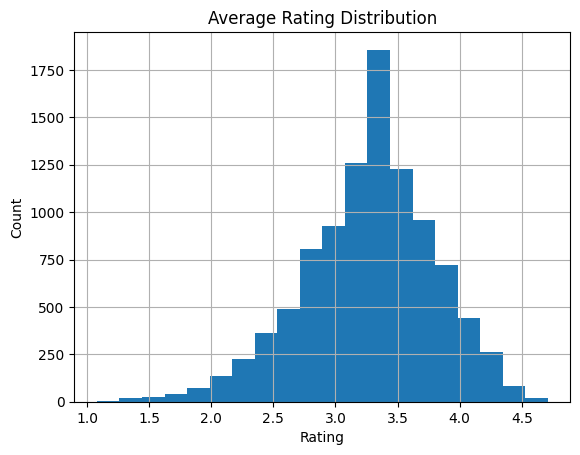

In [224]:
df["Average_rating"].hist(bins=20)

plt.title("Average Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

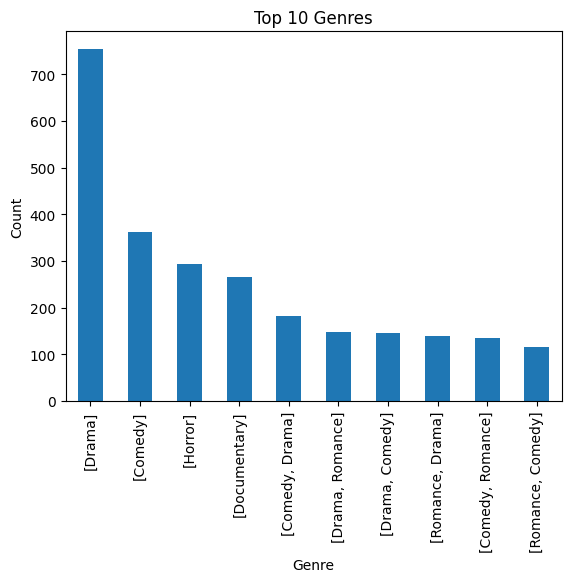

In [225]:
genre_counts = df["Genres"].value_counts()
genre_counts.head(10).plot(kind="bar")

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

In [226]:
genres = genres.drop(columns=fuzzy_genres, errors="ignore"  )
genre_distribution = df[genres.columns].sum().sort_values(ascending=False)
print(genre_distribution)

Drama              4398
Comedy             2923
Thriller           2302
Action             2067
Horror             1805
Crime              1515
Adventure          1444
Romance            1369
Science Fiction    1262
Fantasy             992
Mystery             831
Family              716
Animation           689
History             448
Documentary         426
War                 361
Music               350
Western             282
TV Movie            210
dtype: int64


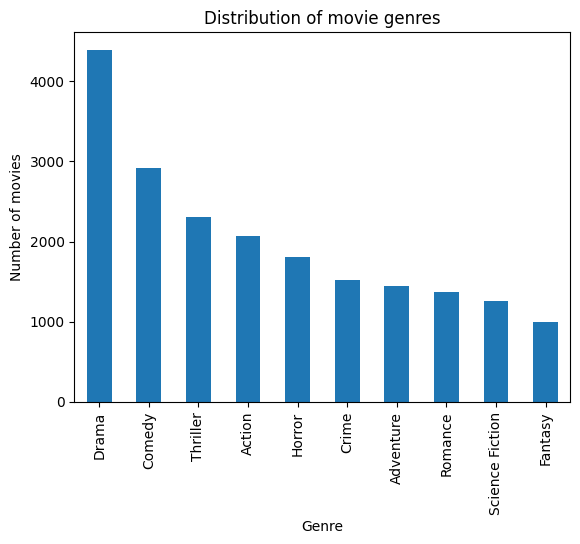

In [227]:
genre_distribution.head(10).plot(kind="bar")

plt.title("Distribution of movie genres")
plt.xlabel("Genre")
plt.ylabel("Number of movies")

plt.show()

In [230]:
df.isnull().sum()

Film_title           0
Director             0
Cast                 0
Average_rating       0
Genres               0
Runtime              0
Countries            0
Original_language    0
Spoken_languages     0
Description          0
Studios              0
Watches              0
List_appearances     0
Likes                0
Fans                 0
½                    0
★                    0
★½                   0
★★                   0
★★½                  0
★★★                  0
★★★½                 0
★★★★                 0
★★★★½                0
★★★★★                0
Total_ratings        0
Action               0
Adventure            0
Animation            0
Comedy               0
Crime                0
Documentary          0
Drama                0
Family               0
Fantasy              0
History              0
Horror               0
Music                0
Mystery              0
Romance              0
Science Fiction      0
TV Movie             0
Thriller             0
War        

In [ ]:
# POTENTIALLY repeat genre steps with categories like "countries" or "languages"
# probably drop cast and studio due to too many unique values

In [231]:
df.to_csv("letterboxd_clean.csv", index=False)